# EDA 1 | Parte 3.2 - Análise dos Textos dos Hinos da ICM
Este notebook explora o conteúdo textual dos hinos da coletânea principal da Igreja Cristã Maranata.

O objetivo é analisar o texto dos louvores, extraindo informações como número de palavras, tokens, frequências, n-grams e similaridade entre hinos.

---
**Conteúdo do notebook:**
- Carregamento dos dados tratados
- Extração de n-grams (bigramas, trigramas)
- Cálculo de similaridade entre hinos (CountVectorizer e TF-IDF)

---

**A seguir:** Importação e preparação da lista de stopwords, combinando fontes externas e do NLTK para uso na tokenização.

In [1]:
import pandas as pd
from pathlib import Path

assets_folder = Path("../assets")
hinos_analise: pd.DataFrame = pd.read_pickle(assets_folder / "hinos_analise_tokens.pkl")
hinos_analise.head()

,nome,texto,texto_processado,categoria_id,categoria,categoria_abr,texto_limpo,tokens,tokens_no_stops,num_tokens,texto_unico,num_tokens_unico
numero,,,,,,,,,,,,
0,AQUILO QUE FUI NÃO SOU MAIS,"AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...","AQUILO QUE FUI NÃO SOU MAIS,\nNEM SOU TUDO O Q...",7.0,VOLTA DE JESUS E ETERNIDADE,VOLTA DE JESU...,"AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QU...","[aquilo, que, fui, não, sou, mais, nem, sou, t...","[tudo, devo, graça, vê, certo, vou, glória, cr...",124,"AQUILO QUE FUI NÃO SOU MAIS, NEM SOU TUDO O QU...",45
1,O SANGUE DE JESUS TEM PODER,"O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...","O SANGUE DE JESUS TEM PODER,\nPODER QUE A MIM ...",1.0,CLAMOR,CLAMOR,"O SANGUE DE JESUS TEM PODER, PODER QUE A MIM P...","[o, sangue, de, jesus, tem, poder, poder, que,...","[sangue, jesus, pode, valer, comunhão, posso, ...",110,"O SANGUE DE JESUS TEM PODER, PODER QUE A MIM P...",29
2,O SANGUE DE JESUS TEM PODER PARA SALVAR,O SANGUE DE JESUS TEM PODER (2x)\nO SANGUE DE ...,O SANGUE DE JESUS TEM PODER <bis tipo='2'>\nO ...,1.0,CLAMOR,CLAMOR,"O SANGUE DE JESUS TEM PODER O SANGUE DE JESUS,...","[o, sangue, de, jesus, tem, poder, o, sangue, ...","[sangue, jesus, sangue, jesus, sangue, jesus, ...",50,"O SANGUE DE JESUS TEM PODER O SANGUE DE JESUS,...",20
3,CLAMO A TI,"CLAMO A TI, Ó MEU SENHOR,\nCLAMO A TI, MEU SAL...","CLAMO A TI, Ó MEU SENHOR,<bis>\nCLAMO A TI, ME...",1.0,CLAMOR,CLAMOR,"CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALV...","[clamo, a, ti, ó, meu, senhor, clamo, a, ti, m...","[clamo, senhor, clamo, salvador, sangue, vida,...",41,"CLAMO A TI, Ó MEU SENHOR, CLAMO A TI, MEU SALV...",17
4,QUANDO TE PROSTRARES,"QUANDO TE PROSTRARES DIANTE DE DEUS,\nLEMBRA Q...","QUANDO TE PROSTRARES DIANTE DE DEUS,<bis>\nLEM...",1.0,CLAMOR,CLAMOR,"QUANDO TE PROSTRARES DIANTE DE DEUS, LEMBRA QU...","[quando, te, prostrares, diante, de, deus, lem...","[prostrares, diante, deus, lembra, jesus, pede...",51,"QUANDO TE PROSTRARES DIANTE DE DEUS, LEMBRA QU...",21


## N-grams

---

**A seguir:** Extração e análise de n-grams (bigramas e trigramas) para identificar padrões de palavras recorrentes nos textos dos hinos.

In [2]:
from collections import Counter
import nltk


# Exemplo: gerar bigramas do corpus inteiro
def get_bigrams(tokens):
    return list(nltk.ngrams(tokens, 2))  # 2 = bigramas


# Gerar bigramas para todos os hinos
hinos_analise["bigrams"] = hinos_analise["tokens_no_stops"].apply(get_bigrams)

# Contar bigramas mais frequentes no corpus inteiro
all_bigrams = [bigram for hino in hinos_analise["bigrams"] for bigram in hino]
bigram_freq = Counter(all_bigrams)

bigram_freq.most_common(10)

[(('senhor', 'jesus'), 54),
 (('grande', 'amor'), 54),
 (('santo', 'santo'), 52),
 (('jesus', 'cristo'), 49),
 (('sangue', 'jesus'), 48),
 (('glória', 'glória'), 46),
 (('amor', 'deus'), 39),
 (('vem', 'jesus'), 35),
 (('vida', 'eterna'), 33),
 (('senhor', 'deus'), 33)]

In [3]:
# Gerar trigramas do corpus inteiro
def get_trigrams(tokens):
    return list(nltk.ngrams(tokens, 3))  # 3 = trigrams


# Gerar trigrams para todos os hinos
hinos_analise["trigrams"] = hinos_analise["tokens_no_stops"].apply(get_trigrams)

# Contar trigrams mais frequentes no corpus inteiro
all_trigrams = [trigram for hino in hinos_analise["trigrams"] for trigram in hino]
trigram_freq = Counter(all_trigrams)

trigram_freq.most_common(10)

[(('santo', 'santo', 'santo'), 31),
 (('glória', 'glória', 'glória'), 20),
 (('vem', 'senhor', 'jesus'), 15),
 (('maranata', 'ora', 'vem'), 11),
 (('ora', 'vem', 'senhor'), 10),
 (('vem', 'vem', 'vem'), 10),
 (('leão', 'tribo', 'judá'), 9),
 (('dai', 'glória', 'deus'), 9),
 (('aleluia', 'aleluia', 'aleluia'), 8),
 (('viva', 'rei', 'viva'), 7)]

## Matriz de frequência e similaridade CountVectorizer

---

**A seguir:** Cálculo de matriz de similaridade entre hinos usando CountVectorizer, visualização com heatmap e identificação de hinos similares por esse método.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Juntar os tokens em strings
hinos_analise["tokens_str"] = hinos_analise["tokens_no_stops"].apply(
    lambda t: " ".join(t)
)

# Criar o vetor de frequências
vectorizer = CountVectorizer(
    ngram_range=(1, 3), stop_words=None
)  # unigramas, bigramas e trigramas
X = vectorizer.fit_transform(hinos_analise["tokens_str"])

# Similaridade de cosseno entre hinos
similarity = cosine_similarity(X)
similarity_df = pd.DataFrame(
    similarity, index=hinos_analise.index, columns=hinos_analise.index
)

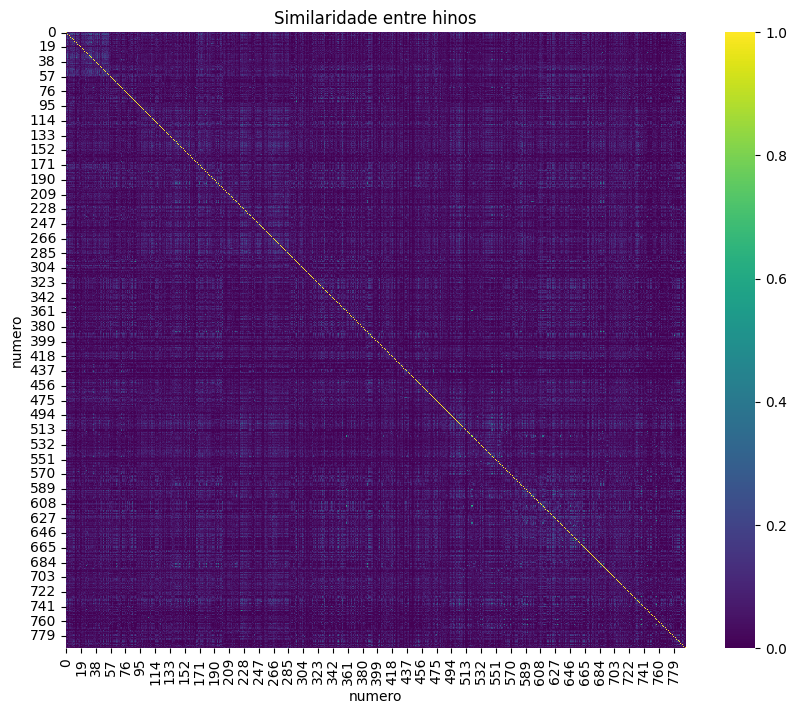

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, cmap="viridis", annot=False)
plt.title("Similaridade entre hinos")
plt.show()

In [6]:
high_similarity = similarity_df[
    (similarity_df > 0.5) & (similarity_df < 1.0)
].stack()  # .reset_index()
high_similarity = high_similarity[
    high_similarity.index.get_level_values(0)
    < high_similarity.index.get_level_values(1)
]
high_similarity.sort_values(ascending=False).head()

numero  numero
757     764       0.766165
521     610       0.666845
359     610       0.665733
653     655       0.649419
738     764       0.648886
dtype: float64

## Matriz com TF-IDF

**A seguir:** Cálculo de matriz de similaridade entre hinos usando TF-IDF, visualização com heatmap e identificação de hinos similares por esse método.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF: unigrams e bigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words=None)
X_tfidf = vectorizer.fit_transform(hinos_analise["tokens_str"])

**A seguir:** Ranking de termos mais relevantes por hino com TF-IDF, destacando palavras-chave que caracterizam cada hino individualmente (uni e bigramas).

In [8]:
import random


def top_terms_for_hymn(row, features, top_n=5):
    row_data = list(zip(features, row))
    row_data = sorted(row_data, key=lambda x: x[1], reverse=True)
    return row_data[:top_n]


features = vectorizer.get_feature_names_out()

# random.seed(42)
sample_idxs = random.sample(range(X_tfidf.shape[0]), 3)

for idx in sample_idxs:
    row = X_tfidf[idx].toarray().ravel()
    top_terms = top_terms_for_hymn(row, features, top_n=3)
    hymn_num = hinos_analise.index[idx]
    hymn_name = hinos_analise.loc[hymn_num, "nome"]
    print(f"\n🎵 Hino {hymn_num} — {hymn_name}:")
    for term, score in top_terms:
        print(f"  {term}: {score:.3f}")


🎵 Hino 194 — QUERO ANDAR EM TEU CAMINHO, SENHOR:
  agradeço: 0.583
  senhor agradeço: 0.277
  agradeço agradeço: 0.185

🎵 Hino 96 — COM A MINHA VOZ CLAMO AO SENHOR:
  livrar: 0.189
  clamo: 0.165
  diante: 0.135

🎵 Hino 717 — A TERRA SEMEAMOS:
  louvai deus: 0.202
  louvai: 0.156
  flor: 0.144


**A seguir:** Construindo a matriz de similaridade entre hinos usando TF-IDF

In [9]:
similarity_tfidf = cosine_similarity(X_tfidf)
similarity_df_tfidf = pd.DataFrame(
    similarity_tfidf, index=hinos_analise.index, columns=hinos_analise.index
)

**A seguir:** Visualização com heatmap e identificação de hinos similares por esse método.

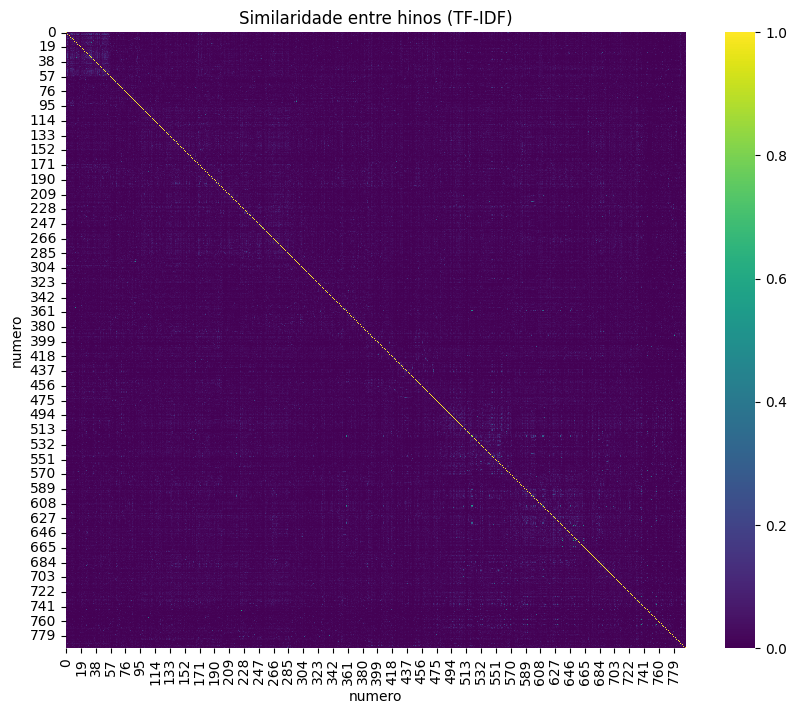

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df_tfidf, cmap="viridis", annot=False)
plt.title("Similaridade entre hinos (TF-IDF)")
plt.show()

In [11]:
high_similarity_tfidf = similarity_df_tfidf[
    (similarity_df_tfidf > 0.5) & (similarity_df_tfidf < 1.0)
].stack()  # .reset_index()
high_similarity_tfidf = high_similarity_tfidf[
    high_similarity_tfidf.index.get_level_values(0)
    < high_similarity_tfidf.index.get_level_values(1)
]
high_similarity_tfidf.sort_values(ascending=False).head(10)

numero  numero
225     746       0.584183
757     764       0.584048
521     610       0.582596
653     655       0.564256
655     663       0.554774
636     651       0.543033
651     655       0.534196
359     610       0.533877
391     780       0.532966
738     764       0.532487
dtype: float64

---

**A seguir:** Exportação dos dados tratados e enriquecidos para arquivo pickle, permitindo reutilização em outras análises ou notebooks.

In [12]:
hinos_analise.to_pickle(assets_folder / "hinos_analise_tokens_ngrams.pkl")